# Algorithm Comparison Ã¢â‚¬â€ PCam

Comparison of UCB search across desired sequence lengths on PatchCamelyon.

**Metrics:** relative probability drop, raw probability drop, log-odds score,
per-image normalized score (min=0 worst, max=1 best among configs for that image),
deletion AUC, insertion AUC, runtime.

**Win counting:** for each image at a fixed length, the config with the highest
normalized score wins. Two variants: no threshold and a decisive-margin threshold.

In [1]:
import os
import re

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
from IPython.display import display

In [2]:
TRACKING_URI = "https://mlflow.rationai.cloud.e-infra.cz/"
EXPERIMENT_NAME = "ucb-comparison-pcam"
os.environ["MLFLOW_TRACKING_USERNAME"] = "YOUR_MLFLOW_USERNAME"
os.environ["MLFLOW_TRACKING_PASSWORD"] = "YOUR_MLFLOW_PASSWORD"

WIN_MARGIN = 0.05
DESIRED_LENGTHS = [10, 20, 40, 60]

## Load & parse MLflow data

In [3]:
mlflow.set_tracking_uri(TRACKING_URI)
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
if experiment is None:
    raise RuntimeError(f"Experiment '{EXPERIMENT_NAME}' not found.")

runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    output_format="pandas",
)
print(f"Total runs fetched: {len(runs)}")

Total runs fetched: 505


In [4]:
parents = runs[runs["tags.mlflow.parentRunId"].isna()].copy()
children = runs[runs["tags.mlflow.parentRunId"].notna()].copy()

_name_re = re.compile(r"^(?P<label>.+)-(?P<seed>\d+)-length-(?P<length>\d+)$")


def _parse_name(name):
    if not isinstance(name, str):
        return None, None, None
    m = _name_re.match(name)
    if not m:
        return name, None, None
    return m.group("label"), int(m.group("seed")), int(m.group("length"))


_parsed = parents["tags.mlflow.runName"].apply(_parse_name)
parents = parents.assign(
    label=_parsed.apply(lambda x: x[0]),
    seed=_parsed.apply(lambda x: x[1]),
    desired_length=_parsed.apply(lambda x: x[2]),
)
parents = parents[parents["desired_length"].notna()].copy()

data = children.merge(
    parents[["run_id", "label", "seed", "desired_length"]],
    left_on="tags.mlflow.parentRunId",
    right_on="run_id",
    suffixes=("", "_parent"),
    how="inner",
)
data["image_name"] = data["tags.mlflow.runName"]
data["desired_length"] = data["desired_length"].astype(int)

print(f"Matched child runs: {len(data)}")
print(f"Labels: {sorted(data['label'].unique())}")
print(f"Lengths: {sorted(data['desired_length'].unique())}")

Matched child runs: 500
Labels: ['ucb']
Lengths: [np.int64(10), np.int64(20), np.int64(40), np.int64(60)]


In [5]:
def _first_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


_prob_col = _first_col(
    data, ["metrics.all_regions/probability_drop", "metrics.region_0/probability_drop"]
)
_score_col = _first_col(
    data, ["metrics.all_regions/final_score", "metrics.region_0/final_score"]
)
_orig_col = _first_col(data, ["metrics.region_0/original_prob"])
_masked_col = _first_col(data, ["metrics.region_0/masked_prob"])
_top_prob_col = _first_col(data, ["metrics.region_0/masked_top_prob"])
_del_col = _first_col(data, ["metrics.deletion_auc"])
_ins_col = _first_col(data, ["metrics.insertion_auc"])
_time_col = _first_col(data, ["metrics.time_seconds"])
_class_col = _first_col(data, ["params.class_name", "params.target_class_name"])
_top_class_col = _first_col(
    data, ["params.region_0/masked_top_class_name", "params.masked_top_class_name"]
)

data = data.copy()
data["prob_drop"] = data[_prob_col].astype(float) if _prob_col else np.nan
data["score"] = data[_score_col].astype(float) if _score_col else np.nan
data["orig_prob"] = data[_orig_col].astype(float) if _orig_col else np.nan
data["masked_prob"] = data[_masked_col].astype(float) if _masked_col else np.nan
data["masked_top_prob"] = data[_top_prob_col].astype(float) if _top_prob_col else np.nan
data["deletion_auc"] = data[_del_col].astype(float) if _del_col else np.nan
data["insertion_auc"] = data[_ins_col].astype(float) if _ins_col else np.nan
data["time"] = data[_time_col].astype(float) if _time_col else np.nan
data["class_name"] = data[_class_col] if _class_col else None
data["masked_top_class"] = data[_top_class_col] if _top_class_col else None
data["rel_drop"] = np.where(
    data["orig_prob"] > 0, data["prob_drop"] / data["orig_prob"], np.nan
)

for name, col in [
    ("prob_drop", _prob_col),
    ("score", _score_col),
    ("deletion_auc", _del_col),
    ("insertion_auc", _ins_col),
    ("time", _time_col),
]:
    print(f"  {name}: {'found: ' + col if col else 'MISSING'}")

METRICS = ["rel_drop", "prob_drop", "score", "deletion_auc", "insertion_auc", "time"]
data[["label", "desired_length", "image_name"] + METRICS].head()

  prob_drop: found: metrics.all_regions/probability_drop
  score: found: metrics.all_regions/final_score
  deletion_auc: found: metrics.deletion_auc
  insertion_auc: found: metrics.insertion_auc
  time: found: metrics.time_seconds


,label,desired_length,image_name,rel_drop,prob_drop,score,deletion_auc,insertion_auc,time
0,ucb,60,pcam_tumor_0020.jpg,1.000000,0.998031,24.902796,0.741828,0.973752,58.944719
1,ucb,60,pcam_normal_0024.jpg,0.369438,0.369418,9.298866,0.999618,0.999974,60.330370
2,ucb,60,pcam_normal_0002.jpg,1.000000,0.569485,23.170025,0.385512,0.856957,60.263708
3,ucb,60,pcam_normal_0038.jpg,0.265496,0.265470,8.206222,0.996295,0.999844,59.988695
4,ucb,60,pcam_tumor_0041.jpg,0.924336,0.919424,7.737526,0.882326,0.999071,59.435068


In [6]:
# Exclude incomplete runs if needed
EXCLUDED = [
    # ("ucb", 60),
]
mask = pd.Series(True, index=data.index)
for label, length in EXCLUDED:
    mask &= ~((data["label"] == label) & (data["desired_length"] == length))
data = data[mask].copy()
print(f"Rows after exclusions: {len(data)}")

Rows after exclusions: 500


## Helper functions

In [7]:
def add_norm_scores(df, metric_col="rel_drop"):
    def _norm(grp):
        mn, mx = grp[metric_col].min(), grp[metric_col].max()
        grp = grp.copy()
        grp["norm_score"] = 0.5 if mx == mn else (grp[metric_col] - mn) / (mx - mn)
        return grp

    return df.groupby(["desired_length", "image_name"], group_keys=False).apply(_norm)


def count_wins(df, score_col, margin=0.0):
    records = []
    for (length, image), grp in df.groupby(["desired_length", "image_name"]):
        valid = grp.dropna(subset=[score_col])
        if len(valid) < 2:
            continue
        ranked = valid.nlargest(len(valid), score_col)
        best = ranked.iloc[0][score_col]
        second = ranked.iloc[1][score_col]
        if margin == 0.0 or (best - second) > margin:
            records.append({"desired_length": length, "label": ranked.iloc[0]["label"]})
    if not records:
        return pd.DataFrame(columns=["desired_length", "label", "wins", "n_decisive"])
    rec_df = pd.DataFrame(records)
    wins = rec_df.groupby(["desired_length", "label"]).size().reset_index(name="wins")
    n_dec = rec_df.groupby("desired_length").size().reset_index(name="n_decisive")
    return wins.merge(n_dec, on="desired_length")


METRIC_LABELS = {
    "rel_drop": "Rel. Drop",
    "prob_drop": "Prob. Drop",
    "score": "Score (log-odds)",
    "norm_score": "Norm. Score",
    "deletion_auc": "Deletion AUC",
    "insertion_auc": "Insertion AUC",
    "time": "Time (s)",
}
ALL_DISPLAY_METRICS = [
    "rel_drop",
    "prob_drop",
    "score",
    "norm_score",
    "deletion_auc",
    "insertion_auc",
    "time",
]


def build_metric_table(df, length=None):
    sub = df if length is None else df[df["desired_length"] == length]
    rows = []
    for label, grp in sub.groupby("label"):
        row = {"Algorithm": label, "n": len(grp)}
        for m in ALL_DISPLAY_METRICS:
            if m in grp.columns:
                vals = grp[m].dropna()
                row[METRIC_LABELS[m]] = (
                    f"{vals.mean():.4f} \u00b1 {vals.std():.4f}"
                    if len(vals) > 0
                    else "\u2014"
                )
        rows.append(row)
    return pd.DataFrame(rows).set_index("Algorithm")


def _wins_for_length(wins_df, length, all_labels):
    sub = (
        wins_df[wins_df["desired_length"] == length]
        if not wins_df.empty
        else pd.DataFrame()
    )
    counts = dict(zip(sub["label"], sub["wins"], strict=False)) if not sub.empty else {}
    n_dec = int(sub["n_decisive"].iloc[0]) if not sub.empty else 0
    return {l: counts.get(l, 0) for l in all_labels}, n_dec


def plot_wins_for_length(wins_no, wins_m, length, labels, ax_no, ax_margin):
    colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"][: len(labels)]
    x = np.arange(len(labels))
    for ax, wins_df, suffix in [
        (ax_no, wins_no, "all wins (n=100)"),
        (ax_margin, wins_m, f"decisive (margin={WIN_MARGIN})"),
    ]:
        counts, n_dec = _wins_for_length(wins_df, length, labels)
        vals = [counts[l] for l in labels]
        total_label = f"decisive={n_dec}/100" if wins_df is wins_m else "total=100"
        ax.bar(x, vals, color=colors)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=15, ha="right", fontsize=9)
        ax.set_ylabel("Images won")
        ax.set_title(f"Win counts Ã¢â‚¬â€ {suffix}\n({total_label})", fontsize=10)
        ax.set_ylim(0, max(max(vals, default=0) * 1.18, 15))
        for i, v in enumerate(vals):
            ax.text(
                i,
                v + 0.5,
                str(v),
                ha="center",
                va="bottom",
                fontsize=11,
                fontweight="bold",
            )
        ax.grid(axis="y", alpha=0.3)

## Compute normalized scores and win counts

In [8]:
data = add_norm_scores(data, metric_col="rel_drop")

wins_no_margin = count_wins(data, "norm_score", margin=0.0)
wins_with_margin = count_wins(data, "norm_score", margin=WIN_MARGIN)

print("Win counts (no margin):")
display(wins_no_margin)
print(f"\nWin counts (margin={WIN_MARGIN}):")
display(wins_with_margin)

TEMP_DIR/ipykernel_17692\2117419084.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(["desired_length", "image_name"], group_keys=False).apply(_norm)


Win counts (no margin):


,desired_length,label,wins,n_decisive
0,10,ucb,100,100



Win counts (margin=0.05):


,desired_length,label,wins,n_decisive
0,10,ucb,99,99


## Per-length analysis


  DESIRED LENGTH = 10   (1 configs, 100 images)


,n,Rel. Drop,Prob. Drop,Score (log-odds),Norm. Score,Deletion AUC,Insertion AUC,Time (s)
Algorithm,,,,,,,,
ucb,200,0.5384 Ã‚Â± 0.4172,0.4840 Ã‚Â± 0.3803,7.8914 Ã‚Â± 11.8132,0.5000 Ã‚Â± 0.4987,0.5757 Ã‚Â± 0.3263,0.8758 Ã‚Â± 0.1717,6.7482 Ã‚Â± 6.4604


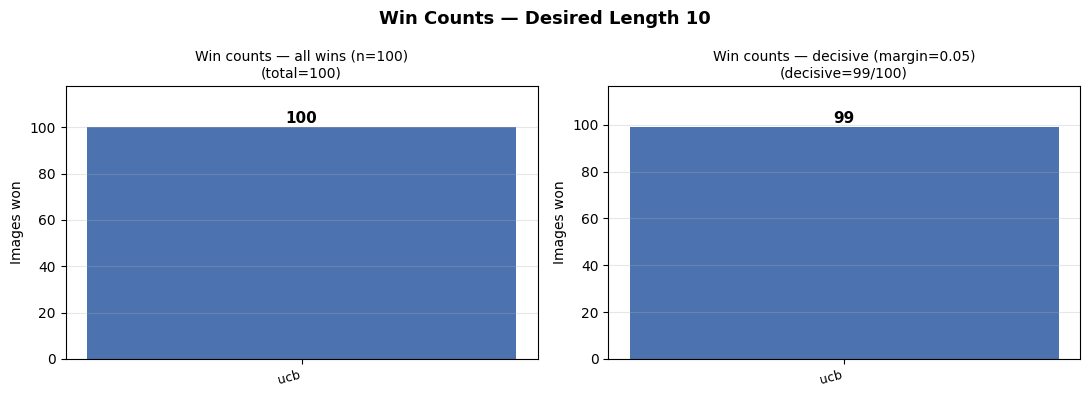


  DESIRED LENGTH = 20   (1 configs, 100 images)


,n,Rel. Drop,Prob. Drop,Score (log-odds),Norm. Score,Deletion AUC,Insertion AUC,Time (s)
Algorithm,,,,,,,,
ucb,100,0.7373 Ã‚Â± 0.3881,0.6778 Ã‚Â± 0.3683,11.2712 Ã‚Â± 12.6700,0.5000 Ã‚Â± 0.0000,0.5757 Ã‚Â± 0.3263,0.8758 Ã‚Â± 0.1717,24.1423 Ã‚Â± 0.6539


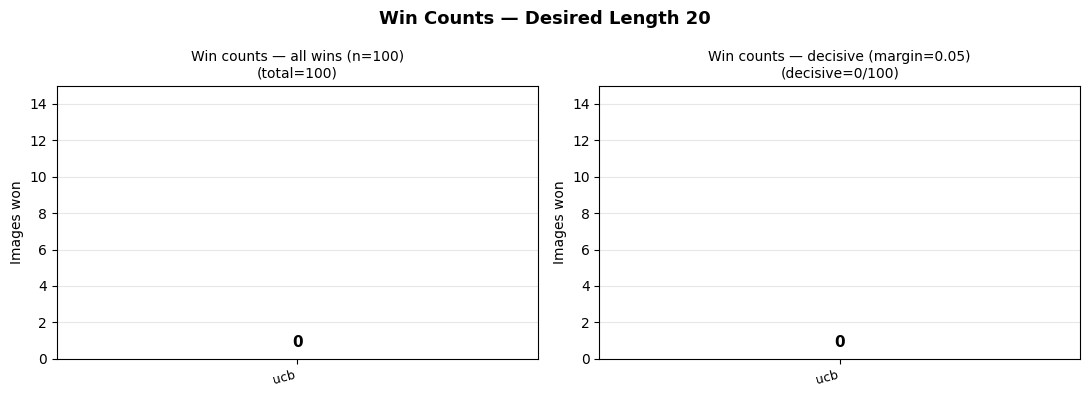


  DESIRED LENGTH = 40   (1 configs, 100 images)


,n,Rel. Drop,Prob. Drop,Score (log-odds),Norm. Score,Deletion AUC,Insertion AUC,Time (s)
Algorithm,,,,,,,,
ucb,100,0.8498 Ã‚Â± 0.3252,0.7887 Ã‚Â± 0.3191,16.9686 Ã‚Â± 14.6947,0.5000 Ã‚Â± 0.0000,0.5757 Ã‚Â± 0.3263,0.8758 Ã‚Â± 0.1717,50.2360 Ã‚Â± 0.7732


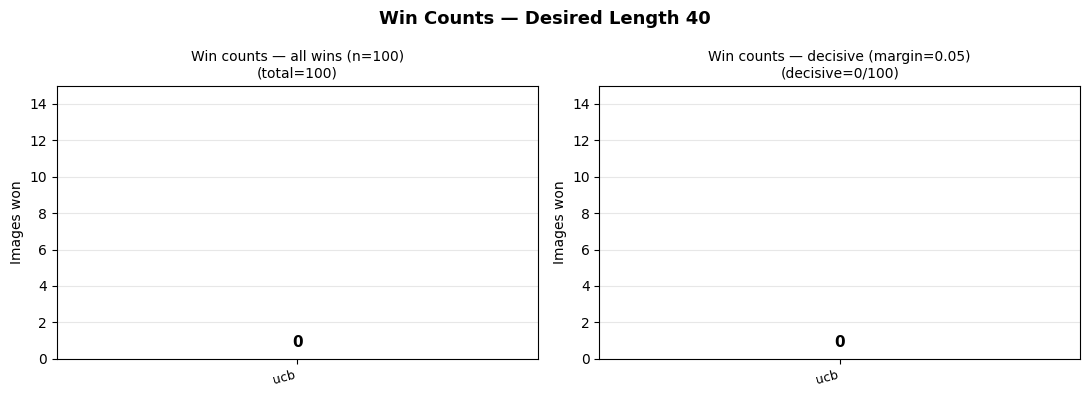


  DESIRED LENGTH = 60   (1 configs, 100 images)


,n,Rel. Drop,Prob. Drop,Score (log-odds),Norm. Score,Deletion AUC,Insertion AUC,Time (s)
Algorithm,,,,,,,,
ucb,100,0.8774 Ã‚Â± 0.3032,0.8163 Ã‚Â± 0.3021,23.5179 Ã‚Â± 19.7887,0.5000 Ã‚Â± 0.0000,0.5757 Ã‚Â± 0.3263,0.8758 Ã‚Â± 0.1717,60.3640 Ã‚Â± 1.0821


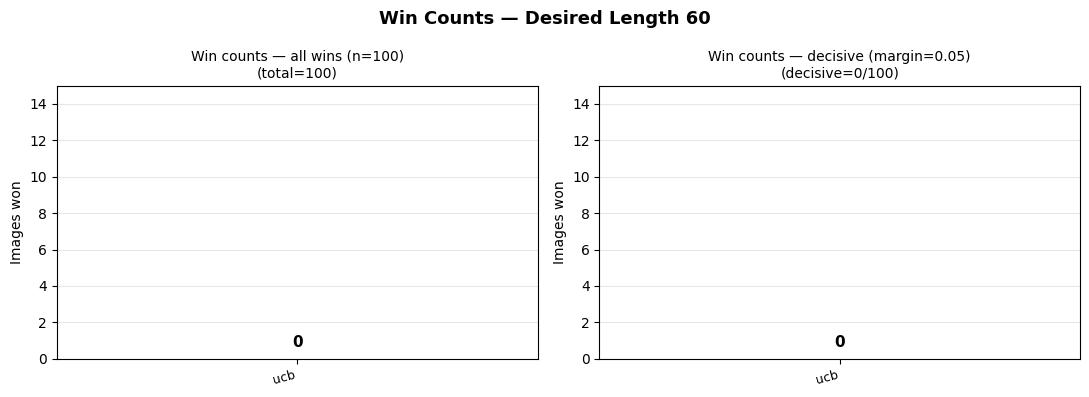

In [9]:
for length in DESIRED_LENGTHS:
    labels = sorted(data[data["desired_length"] == length]["label"].unique())
    print(f"\n{'=' * 70}")
    print(
        f"  DESIRED LENGTH = {length}   ({len(labels)} configs, {len(data[data['desired_length'] == length]['image_name'].unique())} images)"
    )
    print(f"{'=' * 70}")
    display(build_metric_table(data, length=length))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
    fig.suptitle(
        f"Win Counts Ã¢â‚¬â€ Desired Length {length}", fontsize=13, fontweight="bold"
    )
    plot_wins_for_length(wins_no_margin, wins_with_margin, length, labels, ax1, ax2)
    plt.tight_layout()
    plt.show()

## All lengths combined

In [10]:
print(f"{'=' * 70}")
print("  ALL LENGTHS COMBINED")
print(f"{'=' * 70}")

all_labels = sorted(data["label"].unique())

for title, col in [
    ("Mean normalized score", "norm_score"),
    ("Mean relative probability drop", "rel_drop"),
    ("Mean probability drop", "prob_drop"),
    ("Mean log-odds score", "score"),
    ("Mean deletion AUC", "deletion_auc"),
    ("Mean insertion AUC", "insertion_auc"),
]:
    print(f"\n{title}:")
    display(
        data.groupby(["label", "desired_length"])[col]
        .mean()
        .unstack("desired_length")
        .round(4)
    )

print("\nWin counts Ã¢â‚¬â€ no margin (out of 100):")
wn = (
    wins_no_margin.pivot(index="label", columns="desired_length", values="wins")
    .fillna(0)
    .astype(int)
)
display(wn)

print(f"\nWin counts Ã¢â‚¬â€ decisive margin={WIN_MARGIN}:")
wm = (
    wins_with_margin.pivot(index="label", columns="desired_length", values="wins")
    .fillna(0)
    .astype(int)
)
display(wm)

  ALL LENGTHS COMBINED

Mean normalized score:


desired_length,10,20,40,60
label,,,,
ucb,0.5,0.5,0.5,0.5



Mean relative probability drop:


desired_length,10,20,40,60
label,,,,
ucb,0.5384,0.7373,0.8498,0.8774



Mean probability drop:


...

desired_length,10,20,40,60
label,,,,
ucb,0.8758,0.8758,0.8758,0.8758



Win counts Ã¢â‚¬â€ no margin (out of 100):


desired_length,10
label,
ucb,100



Win counts Ã¢â‚¬â€ decisive margin=0.05:


desired_length,10
label,
ucb,99


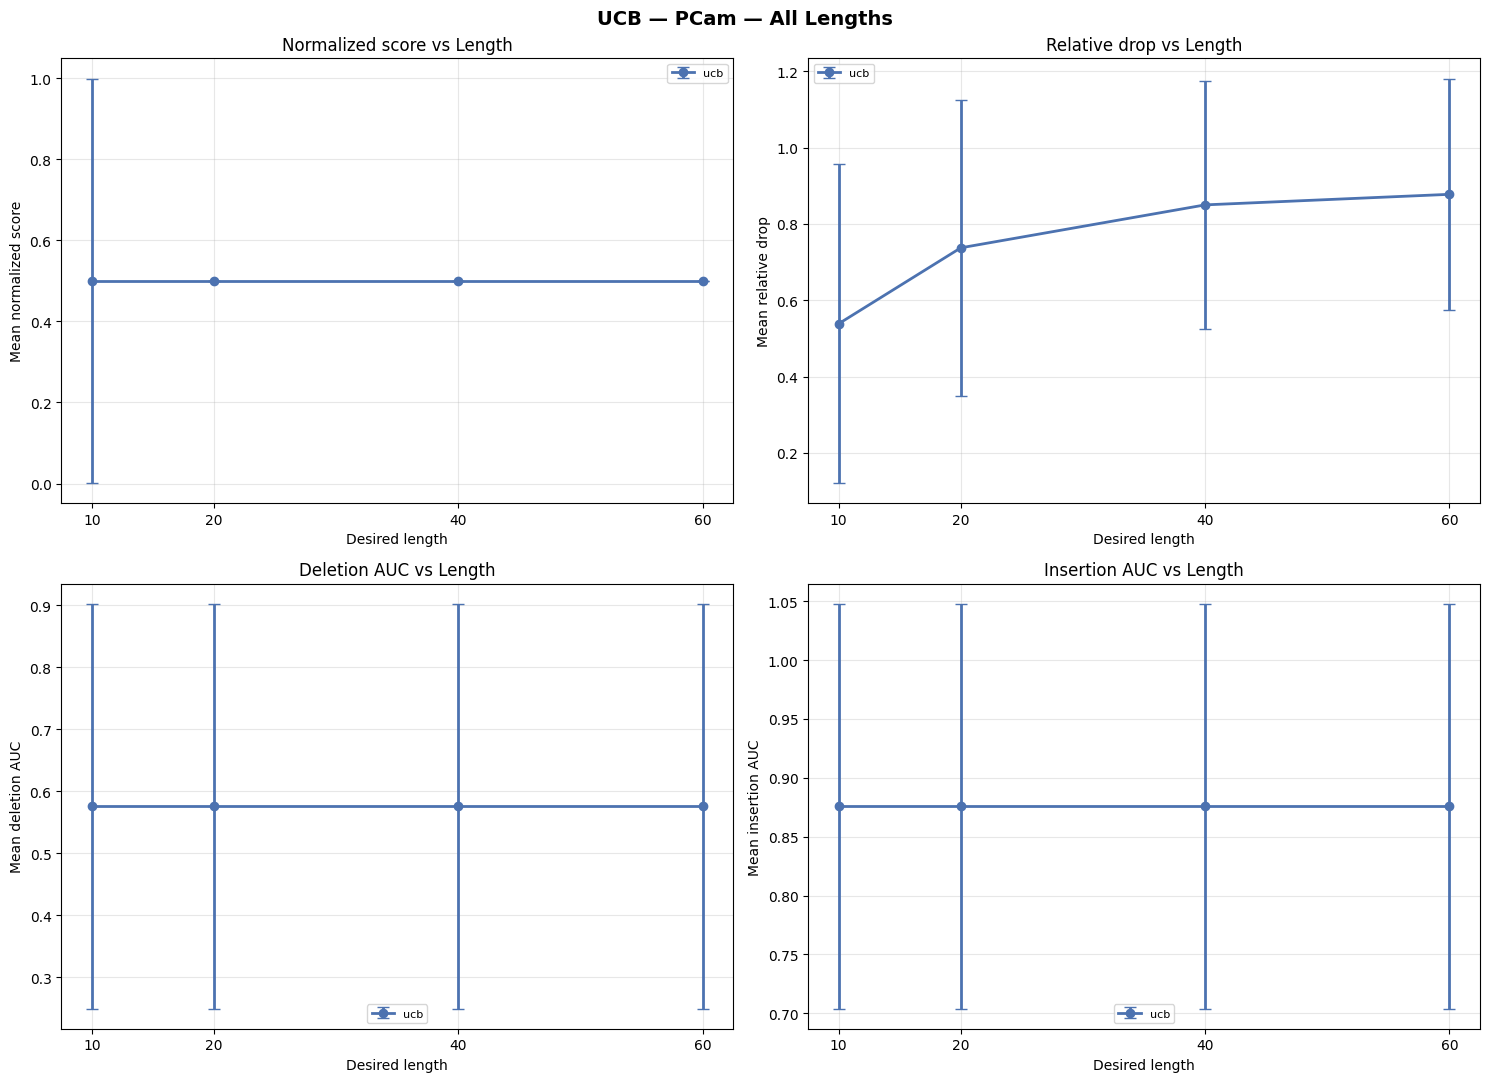

In [11]:
combined = (
    data.groupby(["label", "desired_length"])
    .agg(
        norm_score_mean=("norm_score", "mean"),
        norm_score_std=("norm_score", "std"),
        rel_drop_mean=("rel_drop", "mean"),
        rel_drop_std=("rel_drop", "std"),
        deletion_auc_mean=("deletion_auc", "mean"),
        deletion_auc_std=("deletion_auc", "std"),
        insertion_auc_mean=("insertion_auc", "mean"),
        insertion_auc_std=("insertion_auc", "std"),
    )
    .reset_index()
)

colors_cycle = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]
label_colors = {
    l: colors_cycle[i % len(colors_cycle)]
    for i, l in enumerate(sorted(data["label"].unique()))
}

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle("UCB Ã¢â‚¬â€ PCam Ã¢â‚¬â€ All Lengths", fontsize=14, fontweight="bold")

for ax, y_mean, y_std, ylabel, title in [
    (
        axes[0, 0],
        "norm_score_mean",
        "norm_score_std",
        "Mean normalized score",
        "Normalized score vs Length",
    ),
    (
        axes[0, 1],
        "rel_drop_mean",
        "rel_drop_std",
        "Mean relative drop",
        "Relative drop vs Length",
    ),
    (
        axes[1, 0],
        "deletion_auc_mean",
        "deletion_auc_std",
        "Mean deletion AUC",
        "Deletion AUC vs Length",
    ),
    (
        axes[1, 1],
        "insertion_auc_mean",
        "insertion_auc_std",
        "Mean insertion AUC",
        "Insertion AUC vs Length",
    ),
]:
    for label, grp in combined.groupby("label"):
        grp = grp.sort_values("desired_length")
        ax.errorbar(
            grp["desired_length"],
            grp[y_mean],
            yerr=grp[y_std],
            marker="o",
            label=label,
            color=label_colors[label],
            capsize=4,
            linewidth=2,
        )
    ax.set_xlabel("Desired length")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_xticks(DESIRED_LENGTHS)

plt.tight_layout()
plt.show()

## Decisive win examples

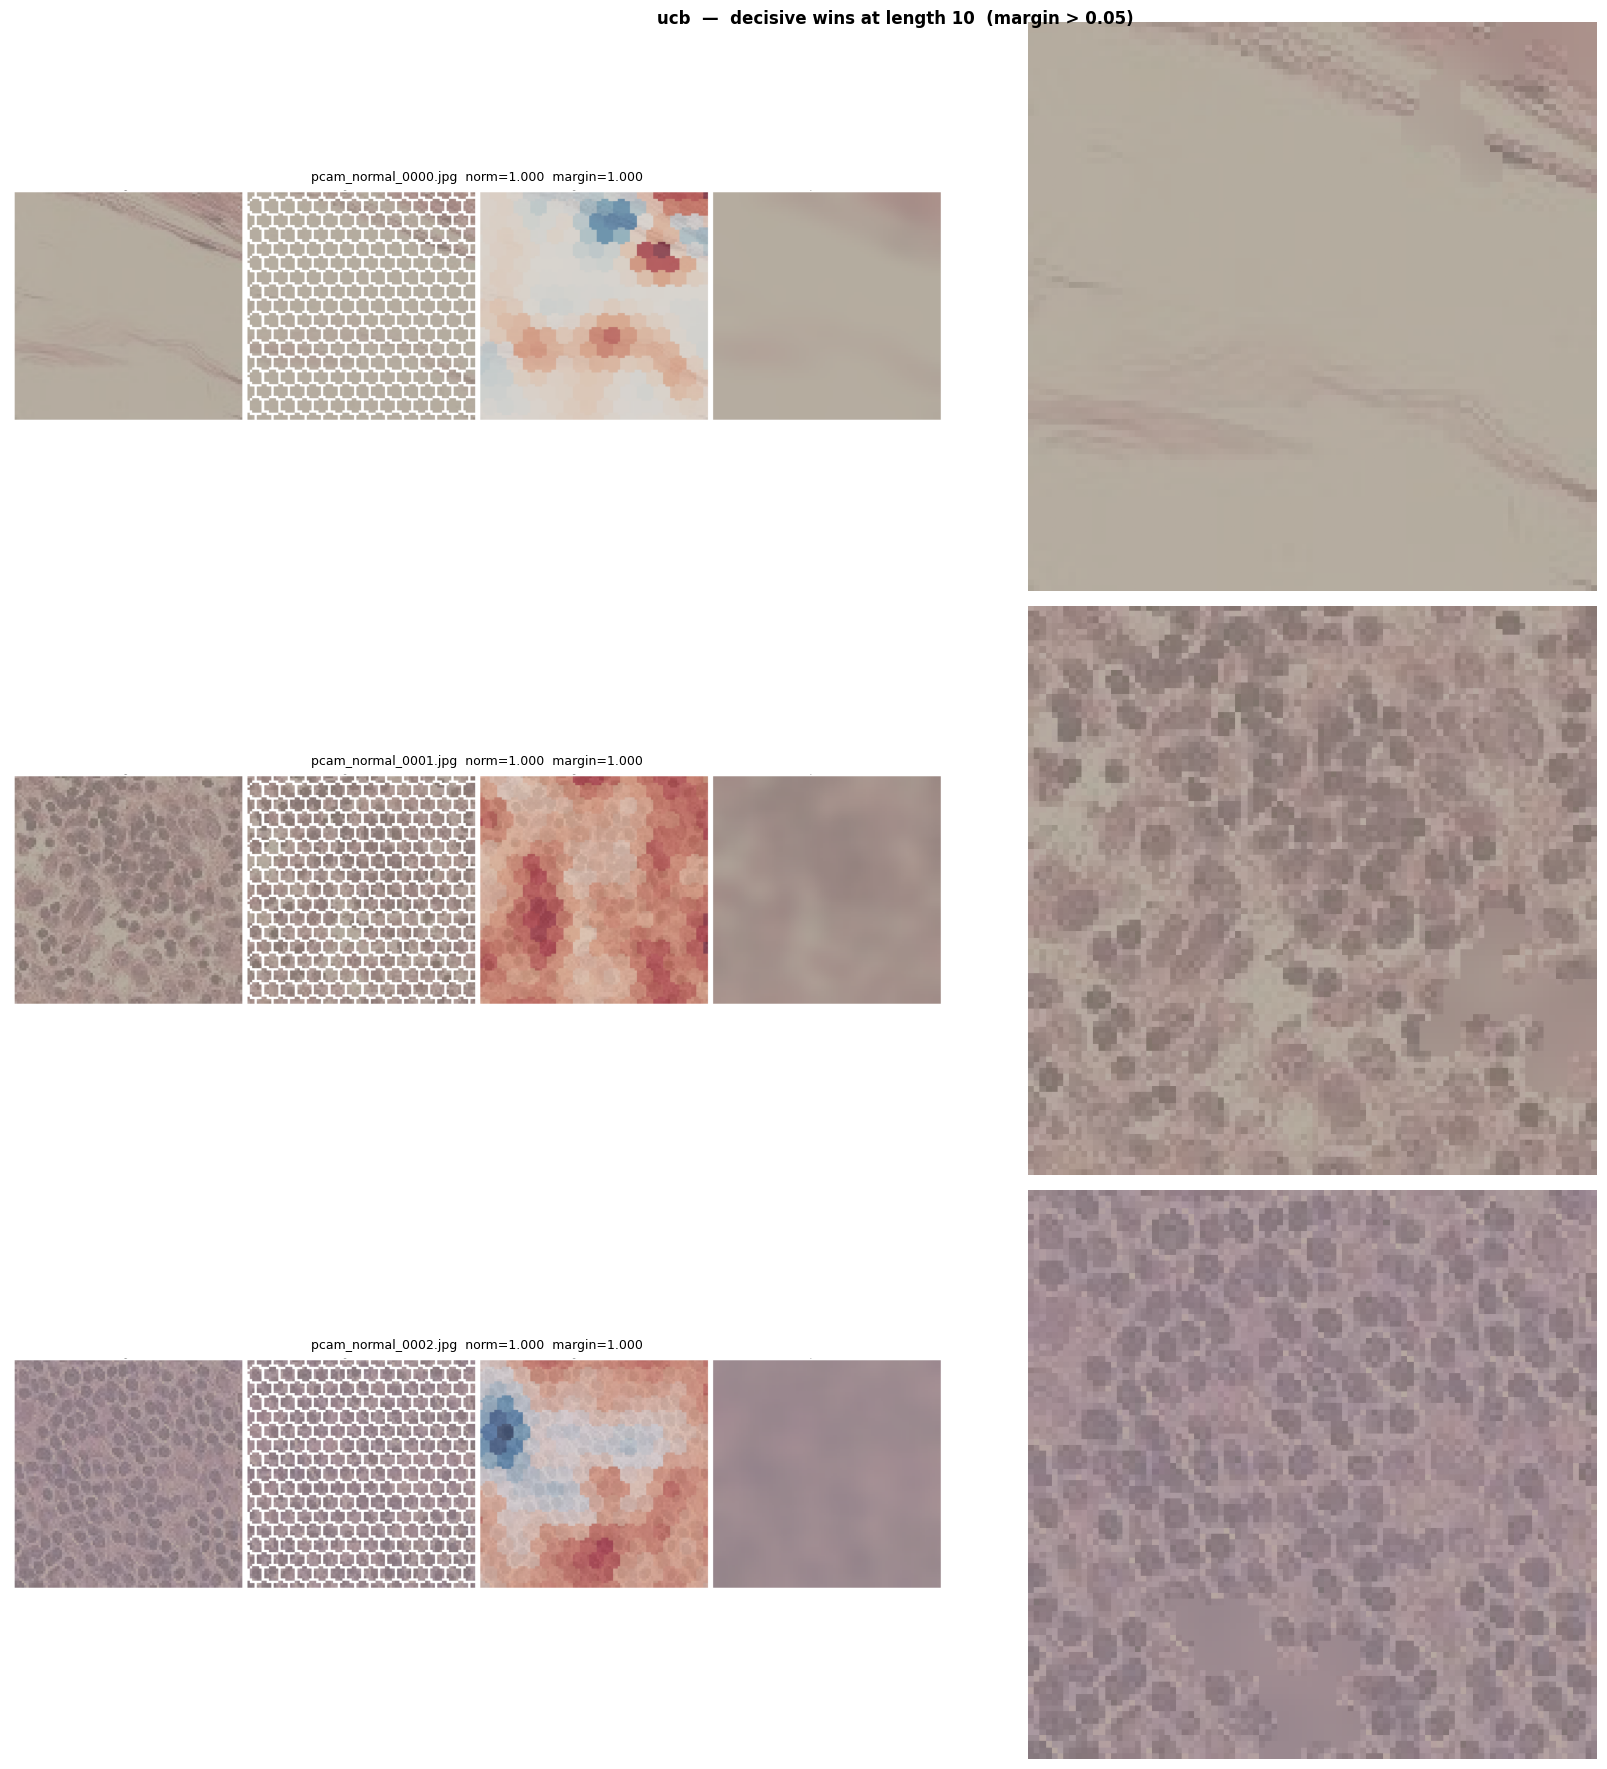

Length 20: no decisive wins found (margin=0.05)
Length 40: no decisive wins found (margin=0.05)
Length 60: no decisive wins found (margin=0.05)


In [12]:
import tempfile

from mlflow.tracking import MlflowClient


N_EXAMPLES = 3
FIGURE_OVERVIEW = "figures/overview.png"
FIGURE_REGIONS = "figures/regions.png"

_client = MlflowClient(tracking_uri=TRACKING_URI)


def get_top_decisive_wins(df, length, margin=WIN_MARGIN, n=N_EXAMPLES):
    sub = df[df["desired_length"] == length]
    per_label = {}
    for image, grp in sub.groupby("image_name"):
        valid = grp.dropna(subset=["norm_score"])
        if len(valid) < 2:
            continue
        ranked = valid.nlargest(len(valid), "norm_score")
        best = ranked.iloc[0]
        margin_val = best["norm_score"] - ranked.iloc[1]["norm_score"]
        if margin_val > margin:
            entry = {
                "image_name": image,
                "run_id": best["run_id"],
                "win_margin": margin_val,
                "norm_score": best["norm_score"],
            }
            per_label.setdefault(best["label"], []).append(entry)
    return {
        label: sorted(wins, key=lambda x: x["win_margin"], reverse=True)[:n]
        for label, wins in per_label.items()
    }


def fetch_figure(run_id, artifact_path):
    try:
        with tempfile.TemporaryDirectory() as tmpdir:
            path = _client.download_artifacts(run_id, artifact_path, dst_path=tmpdir)
            return plt.imread(path)
    except Exception:
        return None


def _clean_ax(ax):
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)


for length in DESIRED_LENGTHS:
    winners = get_top_decisive_wins(data, length)
    if not winners:
        print(f"Length {length}: no decisive wins found (margin={WIN_MARGIN})")
        continue
    for label in sorted(winners.keys()):
        examples = winners[label]
        fig, axes = plt.subplots(
            len(examples), 2, figsize=(18, 6 * len(examples)), squeeze=False
        )
        fig.suptitle(
            f"{label}  Ã¢â‚¬â€  decisive wins at length {length}  (margin > {WIN_MARGIN})",
            fontsize=12,
            fontweight="bold",
        )
        for row_idx, ex in enumerate(examples):
            row = data[data["run_id"] == ex["run_id"]].iloc[0]
            for col, artifact_path in enumerate([FIGURE_OVERVIEW, FIGURE_REGIONS]):
                ax = axes[row_idx][col]
                img = fetch_figure(ex["run_id"], artifact_path)
                if img is not None:
                    ax.imshow(img)
                else:
                    ax.text(
                        0.5,
                        0.5,
                        "artifact not found",
                        ha="center",
                        va="center",
                        transform=ax.transAxes,
                    )
                ax.set_title(
                    f"{ex['image_name']}  norm={ex['norm_score']:.3f}  margin={ex['win_margin']:.3f}"
                    if col == 0
                    else "",
                    fontsize=9,
                )
                _clean_ax(ax)
        plt.tight_layout()
        plt.show()

## UCB vs Baselines

Load baseline runs (GradCAM++, Occlusion, MP, LIME-SLIC) from a separate MLflow
experiment and compare their deletion / insertion AUC against UCB across desired
lengths.

In [13]:
BASELINES_EXPERIMENT_NAME = "baselines-comparison-pcam"

baselines_exp = mlflow.get_experiment_by_name(BASELINES_EXPERIMENT_NAME)
if baselines_exp is None:
    raise RuntimeError(f"Experiment '{BASELINES_EXPERIMENT_NAME}' not found.")

bl_runs = mlflow.search_runs(
    experiment_ids=[baselines_exp.experiment_id],
    output_format="pandas",
)
print(f"Baseline runs fetched: {len(bl_runs)}")

Baseline runs fetched: 404


In [14]:
# Split into parent / child runs; baselines have flat labels (no seed / length)
bl_parents = bl_runs[bl_runs["tags.mlflow.parentRunId"].isna()].copy()
bl_children = bl_runs[bl_runs["tags.mlflow.parentRunId"].notna()].copy()

bl_parents["label"] = bl_parents["tags.mlflow.runName"]

if len(bl_children):
    bl_data = bl_children.merge(
        bl_parents[["run_id", "label"]],
        left_on="tags.mlflow.parentRunId",
        right_on="run_id",
        suffixes=("", "_parent"),
        how="inner",
    )
    bl_data["image_name"] = bl_data["tags.mlflow.runName"]
else:
    # Flat structure: each run IS one image result
    bl_data = bl_parents.copy()
    bl_data["image_name"] = bl_data["tags.mlflow.runName"]

print(f"Baseline data rows: {len(bl_data)}")
print(f"Baseline labels: {sorted(bl_data['label'].unique())}")

Baseline data rows: 400
Baseline labels: ['gradcampp', 'lime-slic', 'mp', 'occlusion']


In [15]:
# Reuse the same column-detection helper as for UCB data
_bl_prob_col = _first_col(
    bl_data,
    ["metrics.all_regions/probability_drop", "metrics.region_0/probability_drop"],
)
_bl_score_col = _first_col(
    bl_data, ["metrics.all_regions/final_score", "metrics.region_0/final_score"]
)
_bl_orig_col = _first_col(bl_data, ["metrics.region_0/original_prob"])
_bl_del_col = _first_col(bl_data, ["metrics.deletion_auc"])
_bl_ins_col = _first_col(bl_data, ["metrics.insertion_auc"])
_bl_time_col = _first_col(bl_data, ["metrics.time_seconds"])

bl_data = bl_data.copy()
bl_data["prob_drop"] = bl_data[_bl_prob_col].astype(float) if _bl_prob_col else np.nan
bl_data["score"] = bl_data[_bl_score_col].astype(float) if _bl_score_col else np.nan
bl_data["orig_prob"] = bl_data[_bl_orig_col].astype(float) if _bl_orig_col else np.nan
bl_data["deletion_auc"] = bl_data[_bl_del_col].astype(float) if _bl_del_col else np.nan
bl_data["insertion_auc"] = bl_data[_bl_ins_col].astype(float) if _bl_ins_col else np.nan
bl_data["time"] = bl_data[_bl_time_col].astype(float) if _bl_time_col else np.nan
bl_data["rel_drop"] = np.where(
    bl_data["orig_prob"] > 0, bl_data["prob_drop"] / bl_data["orig_prob"], np.nan
)

for name, col in [
    ("deletion_auc", _bl_del_col),
    ("insertion_auc", _bl_ins_col),
    ("prob_drop", _bl_prob_col),
    ("rel_drop", None),
]:
    print(f"  {name}: {'found: ' + col if col else 'MISSING'}")

bl_data[
    ["label", "image_name", "deletion_auc", "insertion_auc", "rel_drop", "prob_drop"]
].head()

  deletion_auc: found: metrics.deletion_auc
  insertion_auc: found: metrics.insertion_auc
  prob_drop: found: metrics.region_0/probability_drop
  rel_drop: MISSING


,label,image_name,deletion_auc,insertion_auc,rel_drop,prob_drop
0,lime-slic,pcam_tumor_0020.jpg,0.538133,0.988041,0.164997,0.164672
1,lime-slic,pcam_normal_0024.jpg,0.975446,0.999999,-0.000054,-0.000054
2,lime-slic,pcam_normal_0002.jpg,0.390162,0.894161,-0.711421,-0.405144
3,lime-slic,pcam_normal_0038.jpg,0.992150,0.999965,-0.000047,-0.000047
4,lime-slic,pcam_tumor_0041.jpg,0.503424,0.999738,-0.005212,-0.005185


### Deletion & Insertion AUC Ã¢â‚¬â€ UCB vs Baselines

Baselines appear as horizontal dashed reference lines; UCB variants are plotted
across desired lengths. Lower deletion AUC is **better** (the mask is more faithful);
higher insertion AUC is **better**.

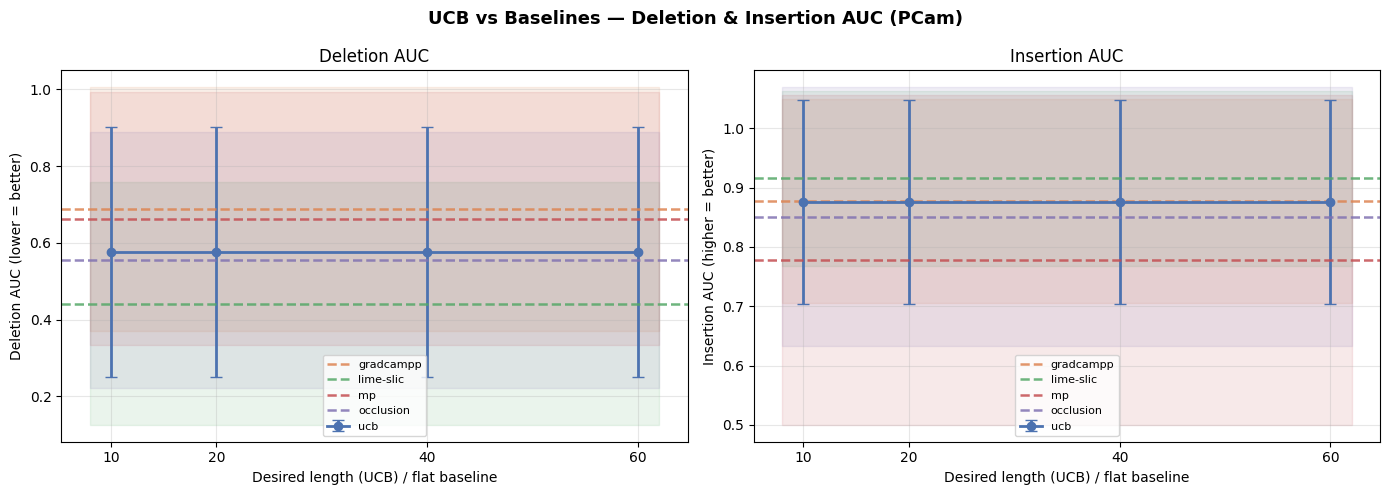

In [16]:
# Aggregate UCB means per label Ãƒâ€” length
ucb_agg = (
    data.groupby(["label", "desired_length"])
    .agg(
        del_mean=("deletion_auc", "mean"),
        del_std=("deletion_auc", "std"),
        ins_mean=("insertion_auc", "mean"),
        ins_std=("insertion_auc", "std"),
    )
    .reset_index()
)

# Aggregate baseline means per label (no length axis)
bl_agg = (
    bl_data.groupby("label")
    .agg(
        del_mean=("deletion_auc", "mean"),
        del_std=("deletion_auc", "std"),
        ins_mean=("insertion_auc", "mean"),
        ins_std=("insertion_auc", "std"),
    )
    .reset_index()
)

ucb_labels = sorted(data["label"].unique())
bl_labels = sorted(bl_data["label"].unique())
colors_ucb = {l: colors_cycle[i % len(colors_cycle)] for i, l in enumerate(ucb_labels)}
colors_bl = {
    l: colors_cycle[(len(ucb_labels) + i) % len(colors_cycle)]
    for i, l in enumerate(bl_labels)
}

fig, (ax_del, ax_ins) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "UCB vs Baselines Ã¢â‚¬â€ Deletion & Insertion AUC (PCam)",
    fontsize=13,
    fontweight="bold",
)

for ax, y_mean, y_std, ylabel, title in [
    (ax_del, "del_mean", "del_std", "Deletion AUC (lower = better)", "Deletion AUC"),
    (ax_ins, "ins_mean", "ins_std", "Insertion AUC (higher = better)", "Insertion AUC"),
]:
    # UCB lines
    for label, grp in ucb_agg.groupby("label"):
        grp = grp.sort_values("desired_length")
        ax.errorbar(
            grp["desired_length"],
            grp[y_mean],
            yerr=grp[y_std],
            marker="o",
            label=label,
            color=colors_ucb[label],
            capsize=4,
            linewidth=2,
        )
    # Baseline horizontal dashed reference lines
    for _, row in bl_agg.iterrows():
        color = colors_bl[row["label"]]
        ax.axhline(
            row[y_mean],
            linestyle="--",
            linewidth=1.8,
            color=color,
            label=row["label"],
            alpha=0.85,
        )
        ax.fill_between(
            [min(DESIRED_LENGTHS) - 2, max(DESIRED_LENGTHS) + 2],
            row[y_mean] - row[y_std],
            row[y_mean] + row[y_std],
            color=color,
            alpha=0.12,
        )
    ax.set_xlabel("Desired length (UCB) / flat baseline")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(DESIRED_LENGTHS)
    ax.legend(fontsize=8, loc="best")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Summary table Ã¢â‚¬â€ all methods

In [ ]:
# UCB: mean Ã‚Â± std across all lengths combined.
# time is already per single-length run (one row per desired_length), so averaging
# across all lengths gives mean time per run Ã¢â‚¬â€ the meaningful cost unit.
ucb_summary = data.groupby("label")[
    ["deletion_auc", "insertion_auc", "rel_drop", "prob_drop", "time"]
].agg(["mean", "std"])
ucb_summary.columns = ["_".join(c) for c in ucb_summary.columns]

# Baseline summary
bl_summary = bl_data.groupby("label")[
    ["deletion_auc", "insertion_auc", "rel_drop", "prob_drop", "time"]
].agg(["mean", "std"])
bl_summary.columns = ["_".join(c) for c in bl_summary.columns]

combined_summary = pd.concat([ucb_summary, bl_summary])


def _fmt(df, base):
    mn = df.get(f"{base}_mean", pd.Series(dtype=float))
    sd = df.get(f"{base}_std", pd.Series(dtype=float))
    return pd.Series(
        [
            f"{m:.4f} Ã‚Â± {s:.4f}" if pd.notna(m) else "Ã¢â‚¬â€"
            for m, s in zip(mn, sd, strict=False)
        ],
        index=df.index,
    )


def _fmt_time(df):
    mn = df.get("time_mean", pd.Series(dtype=float))
    sd = df.get("time_std", pd.Series(dtype=float))
    return pd.Series(
        [
            f"{m:.2f} Ã‚Â± {s:.2f}" if pd.notna(m) else "Ã¢â‚¬â€"
            for m, s in zip(mn, sd, strict=False)
        ],
        index=df.index,
    )


display_df = pd.DataFrame(
    {
        "Deletion AUC": _fmt(combined_summary, "deletion_auc"),
        "Insertion AUC": _fmt(combined_summary, "insertion_auc"),
        "Rel. Drop": _fmt(combined_summary, "rel_drop"),
        "Prob. Drop": _fmt(combined_summary, "prob_drop"),
        "Time (s)Ã¢â€ â€œ": _fmt_time(combined_summary),
    }
)
display_df.index.name = "Algorithm"
display(display_df)

### Per-image paired comparison Ã¢â‚¬â€ UCB (best length) vs Baselines

For each image, pick the UCB run with the best `deletion_auc` across all desired
lengths, then compare directly with baseline values on that image.

In [18]:
COMPARE_METRIC = "deletion_auc"  # change to "insertion_auc", "rel_drop", etc.

# Best UCB result per (label, image) across all lengths
ucb_best = data.loc[data.groupby(["label", "image_name"])[COMPARE_METRIC].idxmax()][
    ["label", "image_name", COMPARE_METRIC, "desired_length"]
].rename(columns={COMPARE_METRIC: "ucb_value"})

# Baseline value per image
bl_img = bl_data[["label", "image_name", COMPARE_METRIC]].rename(
    columns={"label": "bl_label", COMPARE_METRIC: "bl_value"}
)

# Cross-join UCB Ãƒâ€” baselines on image_name
paired = ucb_best.merge(bl_img, on="image_name", how="inner")
print(f"Paired rows: {len(paired)}")

print(f"\nFraction of images where UCB (best length) > baseline ({COMPARE_METRIC}):")
for bl_label, grp in paired.groupby("bl_label"):
    for ucb_label, sub in grp.groupby("label"):
        frac = (sub["ucb_value"] > sub["bl_value"]).mean()
        print(f"  {ucb_label} vs {bl_label}: {frac:.2%} ({len(sub)} images)")

Paired rows: 400

Fraction of images where UCB (best length) > baseline (deletion_auc):
  ucb vs gradcampp: 15.00% (100 images)
  ucb vs lime-slic: 72.00% (100 images)
  ucb vs mp: 23.00% (100 images)
  ucb vs occlusion: 60.00% (100 images)


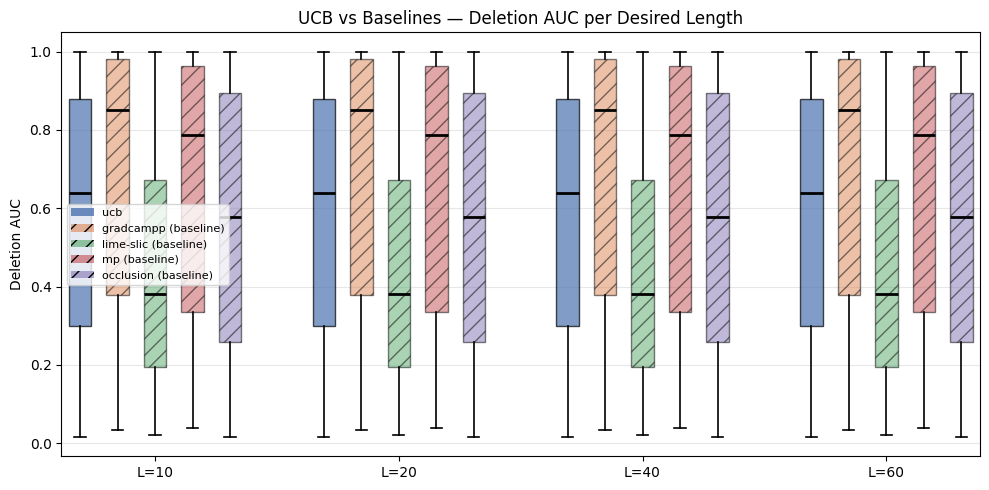

In [19]:
import matplotlib.patches as mpatches


fig, ax = plt.subplots(figsize=(max(10, 2 * len(ucb_labels) + 4), 5))

ucb_colors_list = [colors_ucb[l] for l in ucb_labels]
bl_colors_list = [colors_bl[l] for l in bl_labels]

pos = 0
xtick_pos, xtick_labels = [], []

for length in DESIRED_LENGTHS:
    start = pos
    for i, label in enumerate(ucb_labels):
        vals = data[(data["label"] == label) & (data["desired_length"] == length)][
            COMPARE_METRIC
        ].dropna()
        ax.boxplot(
            vals,
            positions=[pos],
            widths=0.6,
            patch_artist=True,
            boxprops=dict(facecolor=ucb_colors_list[i], alpha=0.7),
            medianprops=dict(color="black", linewidth=2),
            whiskerprops=dict(linewidth=1.2),
            capprops=dict(linewidth=1.2),
            flierprops=dict(marker=".", markersize=3, alpha=0.4),
        )
        pos += 1
    for j, bl_label in enumerate(bl_labels):
        vals = bl_data[bl_data["label"] == bl_label][COMPARE_METRIC].dropna()
        ax.boxplot(
            vals,
            positions=[pos],
            widths=0.6,
            patch_artist=True,
            boxprops=dict(facecolor=bl_colors_list[j], alpha=0.5, hatch="//"),
            medianprops=dict(color="black", linewidth=2),
            whiskerprops=dict(linewidth=1.2),
            capprops=dict(linewidth=1.2),
            flierprops=dict(marker=".", markersize=3, alpha=0.4),
        )
        pos += 1
    xtick_pos.append((start + pos - 1) / 2)
    xtick_labels.append(f"L={length}")
    pos += 1.5  # gap between length groups

ax.set_xticks(xtick_pos)
ax.set_xticklabels(xtick_labels, fontsize=10)
ax.set_ylabel(METRIC_LABELS.get(COMPARE_METRIC, COMPARE_METRIC))
ax.set_title(
    f"UCB vs Baselines Ã¢â‚¬â€ {METRIC_LABELS.get(COMPARE_METRIC, COMPARE_METRIC)} per Desired Length"
)
ax.grid(axis="y", alpha=0.3)

legend_handles = [
    mpatches.Patch(facecolor=colors_ucb[l], alpha=0.8, label=l) for l in ucb_labels
] + [
    mpatches.Patch(
        facecolor=colors_bl[l], alpha=0.6, hatch="//", label=f"{l} (baseline)"
    )
    for l in bl_labels
]
ax.legend(handles=legend_handles, fontsize=8, loc="best")
plt.tight_layout()
plt.show()

### Timing analysis

In [ ]:
# UCB time per desired length
ucb_time_agg = (
    data.groupby(["label", "desired_length"])["time"].agg(["mean", "std"]).reset_index()
)

# Baseline time (no length axis)
bl_time_agg = bl_data.groupby("label")["time"].agg(["mean", "std"]).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Time per image (seconds) Ã¢â‚¬â€ UCB vs Baselines (PCam)",
    fontsize=13,
    fontweight="bold",
)

# Left: UCB time vs desired length with baseline reference lines
ax = axes[0]
for label, grp in ucb_time_agg.groupby("label"):
    grp = grp.sort_values("desired_length")
    ax.errorbar(
        grp["desired_length"],
        grp["mean"],
        yerr=grp["std"],
        marker="o",
        label=label,
        color=colors_ucb[label],
        capsize=4,
        linewidth=2,
    )
for _, row in bl_time_agg.iterrows():
    color = colors_bl[row["label"]]
    ax.axhline(
        row["mean"],
        linestyle="--",
        linewidth=1.8,
        color=color,
        label=row["label"],
        alpha=0.85,
    )
    ax.fill_between(
        [min(DESIRED_LENGTHS) - 2, max(DESIRED_LENGTHS) + 2],
        row["mean"] - row["std"],
        row["mean"] + row["std"],
        color=color,
        alpha=0.12,
    )
ax.set_xlabel("Desired length (UCB) / flat baseline")
ax.set_ylabel("Mean time (s)")
ax.set_title("Time vs desired length")
ax.set_xticks(DESIRED_LENGTHS)
ax.legend(fontsize=8, loc="best")
ax.grid(alpha=0.3)

# Right: per-image distribution (violin) Ã¢â‚¬â€ UCB mean-across-lengths vs baselines
ax = axes[1]
all_labels_ordered = sorted(data["label"].unique()) + sorted(bl_data["label"].unique())
all_colors = {l: colors_ucb.get(l, colors_bl.get(l)) for l in all_labels_ordered}

# For UCB: use mean time per image across desired lengths
ucb_per_image = data.groupby(["label", "image_name"])["time"].mean().reset_index()
plot_data = {
    l: ucb_per_image[ucb_per_image["label"] == l]["time"].dropna().values
    for l in sorted(data["label"].unique())
}
plot_data.update(
    {
        l: bl_data[bl_data["label"] == l]["time"].dropna().values
        for l in sorted(bl_data["label"].unique())
    }
)

positions = list(range(len(all_labels_ordered)))
non_empty = [
    (i, plot_data[l]) for i, l in enumerate(all_labels_ordered) if len(plot_data[l]) > 1
]
if non_empty:
    pos_list, data_list = zip(*non_empty, strict=False)
    parts = ax.violinplot(list(data_list), positions=list(pos_list), showmedians=True)
    for i, pc in enumerate(parts["bodies"]):
        pc.set_facecolor(all_colors[all_labels_ordered[pos_list[i]]])
        pc.set_alpha(0.7)

ax.set_xticks(positions)
ax.set_xticklabels(all_labels_ordered, rotation=20, ha="right", fontsize=9)
ax.set_ylabel("Time (s)")
ax.set_title("Per-image distribution\n(UCB = mean across desired lengths)")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Summary table
print("\nTiming summary (seconds per image):")
ucb_t = (
    ucb_per_image.groupby("label")["time"]
    .agg(["count", "mean", "std", "median", "min", "max"])
    .round(2)
)
bl_t = (
    bl_data.groupby("label")["time"]
    .agg(["count", "mean", "std", "median", "min", "max"])
    .round(2)
)
time_summary = pd.concat([ucb_t, bl_t]).rename(columns={"count": "N"})
time_summary.index.name = "Algorithm"
display(time_summary)